In [7]:
import math as mt 
def prim(graph, start):
    visited = []                #Tracks which nodes have been visited
    visited.append(start)       #Start with the user input node
    result = []                 #Stores the edges in the MST
    total = 0                   #Tracks the total weight of the MST
    while len(visited) < len(graph):   # keep going until all nodes are visited
        min_weight = mt.inf            # Initialize min weight to infinity
        min_edge = None                # Initialize min edge to None

        for node in visited:  # Iterate through visited nodes
            for neighbor, weight in graph[node]: # Iterate through neighbors of the visited node
                if neighbor not in visited and weight < min_weight: # If the neighbor is not visited and the weight is less than the current min weight
                    min_weight = weight  # Update the min weight
                    min_edge = (node, neighbor, weight)  # Update the min edge
        visited.append(min_edge[1]) # Add the new node to visited
        result.append(min_edge) # Add the edge to the result
        total = total + min_weight # Add the weight of the edge to the total
    return result, total


# the graph
graph = {
    'a': [('b', 4), ('h', 8)],
    'b': [('a', 4), ('c', 8), ('h', 11)],
    'c': [('b', 8), ('d', 7), ('i', 2), ('f', 4)],
    'd': [('c', 7), ('e', 9), ('f', 14)],
    'e': [('d', 9), ('f', 10)],
    'f': [('c', 4), ('d', 14), ('e', 10), ('g', 2)],
    'g': [('f', 2), ('h', 1), ('i', 6)],
    'h': [('a', 8), ('b', 11), ('g', 1), ('i', 7)],
    'i': [('c', 2), ('g', 6), ('h', 7)]}
s = input("Enter starting vertex: ")
edges, total = prim(graph, s)
print("MST Edges:")
for e in edges:
    print(e[0], "--", e[1], "weight:", e[2])
print("Total cost:", total)

MST Edges:
a -- b weight: 4
a -- h weight: 8
h -- g weight: 1
g -- f weight: 2
f -- c weight: 4
c -- i weight: 2
c -- d weight: 7
d -- e weight: 9
Total cost: 37


In [8]:
# importing libraries
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

In [9]:
# implementing topological sort 
def topological_sort(graph_dict):
    in_degree = {u: 0 for u in graph_dict} # Initialize in-degree of all vertices to 0
    for u in graph_dict:                   # Calculate in-degree of each vertex
        for v in graph_dict[u]:            # Iterate through neighbors
            in_degree[v] = in_degree.get(v, 0) + 1 # Increment in-degree of neighbor
    queue = deque([u for u in graph_dict if in_degree[u] == 0]) # Enqueue vertices with in-degree 0
    topo_order = [] # List to store the topological order
    while queue:    # Process vertices until the queue is empty
        u = queue.popleft()  # Dequeue a vertex
        topo_order.append(u) # Add it to the topological order
        for v in graph_dict.get(u, []): # Iterate through neighbors of the dequeued vertex
            in_degree[v] -= 1 # Decrease in-degree of neighbor
            if in_degree[v] == 0:  # If in-degree becomes 0, enqueue the neighbor
                queue.append(v)    
    if len(topo_order) != len(graph_dict): # If the topological order does not contain all vertices, there is a cycle
        return "Graph contains a cycle; Topological Sort not possible."
    return topo_order 

In [10]:
# Function to visualize graph and solve topological sort
def visualize_and_solve(adj_list, title, subplot_pos):
    # Create NetworkX graph
    G = nx.DiGraph(adj_list)
    # Plotting
    plt.subplot(2, 2, subplot_pos)
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', 
            node_size=2000, edge_color='gray', arrowsize=20, font_weight='bold')
    plt.title(title)
    # Apply Sorting
    order = topological_sort(adj_list)
    print(f"Topological Order for {title}: {order}")

Topological Order for Graph 1 : ['A', 'B', 'C', 'D', 'E']
Topological Order for Graph 2 : ['5', '4', '2', '0', '3', '1']
Topological Order for Graph 3 : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Topological Order for Graph 4 : ['0', '1', '2', '3', '4', '5', '6', '7']


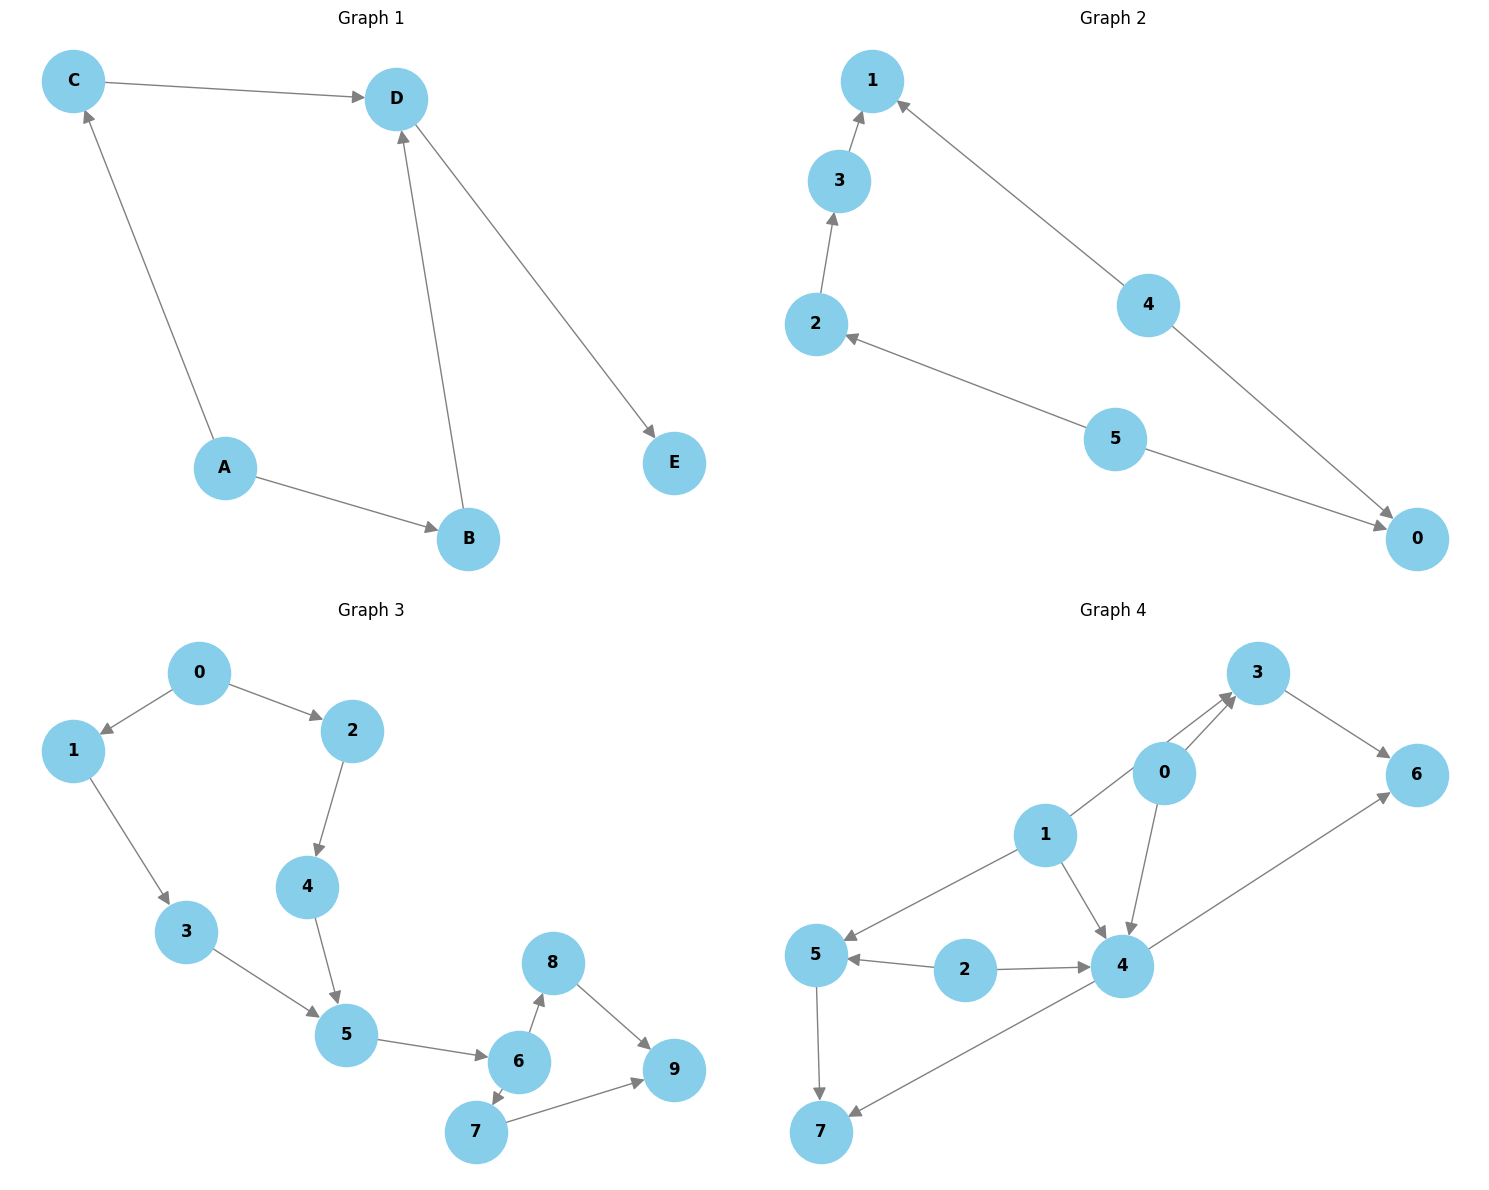

In [11]:
# some sample graphs
graph_1 = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['D'],
    'D': ['E'],
    'E': []}
graph_2 = {
    '5': ['2', '0'],
    '4': ['0', '1'],
    '2': ['3'],
    '3': ['1'],
    '0': [],
    '1': []}

graph_3 = {
    '0': ['1', '2'],
    '1': ['3'],
    '2': ['4'],
    '3': ['5'],
    '4': ['5'],
    '5': ['6'],
    '6': ['7', '8'],
    '7': ['9'],
    '8': ['9'],
    '9': []}

graph_4 = {
    '0': ['3', '4'],
    '1': ['3', '4', '5'],
    '2': ['4', '5'],
    '3': ['6'],
    '4': ['6', '7'],
    '5': ['7'],
    '6': [],
    '7': []}

graph_with_cycle = {                                                                                                                                
         'A': ['B'],                                                                                                                                     
         'B': ['C'],                                                                                                                                     
         'C': ['A']  }




plt.figure(figsize=(15, 12))
visualize_and_solve(graph_1, "Graph 1 ", 1)
visualize_and_solve(graph_2, "Graph 2 ", 2)
visualize_and_solve(graph_3, "Graph 3 ", 3)
visualize_and_solve(graph_4, "Graph 4 ", 4)
plt.tight_layout()
plt.show()

In [12]:
# Testing graph with cycle
print("Testing graph with cycle:")
order = topological_sort(graph_with_cycle)
print(f"Topological Order for graph with cycle: {order}")

Testing graph with cycle:
Topological Order for graph with cycle: Graph contains a cycle; Topological Sort not possible.
